##### ARTI 560 - Computer Vision

## Object Detection Using YOLOV8 with KerasCV - Exercise 

### Objective

In this exercise, you wil learn how to use the pre-trained YOLOV8 model from KerasCV to detect objects in images.

You will:

1. Load the pre-trained YOLOV8 model from KerasCV using the [Pascal VOC preset](https://www.kaggle.com/models/keras/yolov8)

2. Load 5 images for different classes in [Pascal VOC 2012 dataset](https://datasetninja.com/pascal-voc-2012) and convert it into a NumPy array suitable for the model.

3. Resize the images before inference to match the model’s expected input size using:
    ```
    inference_resizing = keras_cv.layers.Resizing(
        640, 640, pad_to_aspect_ratio=True, bounding_box_format="xywh"
    )
    ```

    **Note:** Resizing ensures that the images fit the model input, maintains aspect ratio, and correctly adjusts bounding boxes.

4. Run the YOLOV8 detector on each image to predict bounding boxes, class labels, and confidence scores.

5. Visualize the predictions by drawing the bounding boxes and labels on the images.

6. Record for each image:

    - Which objects were detected correctly

    - The confidence scores of the detections

    - Any missed or incorrectly labeled objects

In [3]:
!pip -q install -U "tensorflow>=2.16" "keras>=3.0.0" "keras-cv>=0.9.0" tensorflow-datasets pandas matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 4.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 620.7/620.7 MB 2.7 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 51.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 650.7/650.7 kB 30.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 83.0 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 106.7 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 80.2 MB/s eta 0:00:00ta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 950.8/950.8 kB 29.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.1 wh

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/3 [00:00<?, ? splits/s]

...

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/voc/2012/incomplete.BL0346_5.0.0/voc-train.tfrecord*...:   0%|          | …

Generating validation examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/voc/2012/incomplete.BL0346_5.0.0/voc-validation.tfrecord*...:   0%|       …

Dataset voc downloaded and prepared to /root/tensorflow_datasets/voc/2012/5.0.0. Subsequent calls will reuse this data.

Searching for different images in VOC2012...
TARGET_CLASSES: ['person', 'dog', 'cat', 'car', 'bicycle']
PICK_INDEX: {'person': 8, 'dog': 12, 'cat': 15, 'car': 10, 'bicycle': 7}
✅ Picked 'person' at match #8 | GT in image: ['chair', 'person']
✅ Picked 'car' at match #10 | GT in image: ['car', 'person']
✅ Picked 'bicycle' at match #7 | GT in image: ['bicycle']
✅ Picked 'dog' at match #12 | GT in image: ['dog']
✅ Picked 'cat' at match #15 | GT in image: ['cat']

=== Image 1/5 | Target class: person | GT objects: ['chair', 'person'] ===


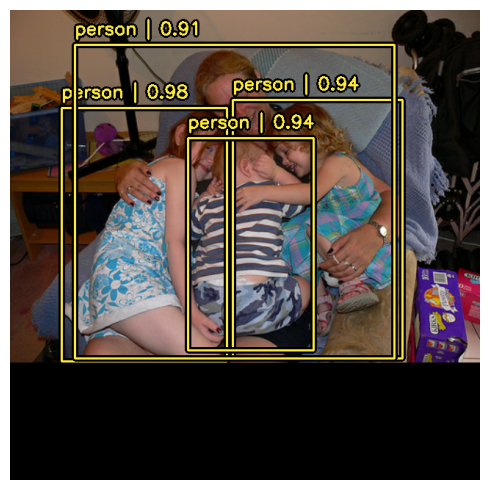


=== Image 2/5 | Target class: dog | GT objects: ['dog'] ===


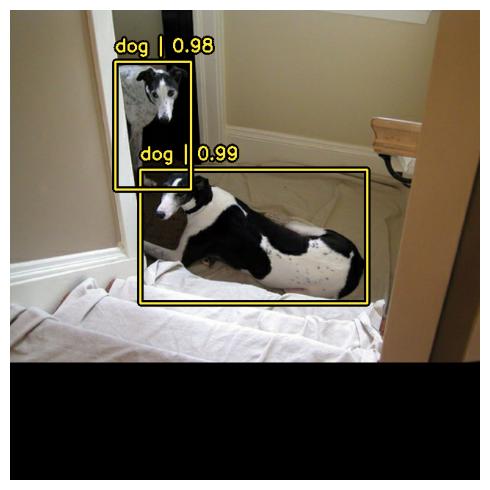


=== Image 3/5 | Target class: cat | GT objects: ['cat'] ===


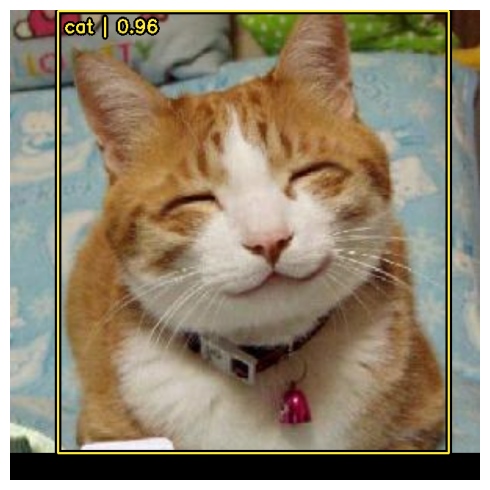


=== Image 4/5 | Target class: car | GT objects: ['car', 'person'] ===


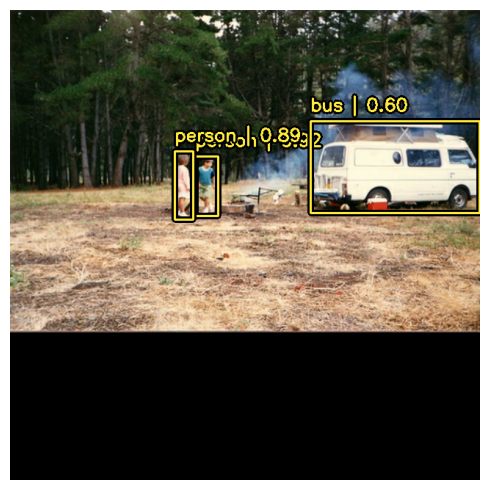


=== Image 5/5 | Target class: bicycle | GT objects: ['bicycle'] ===


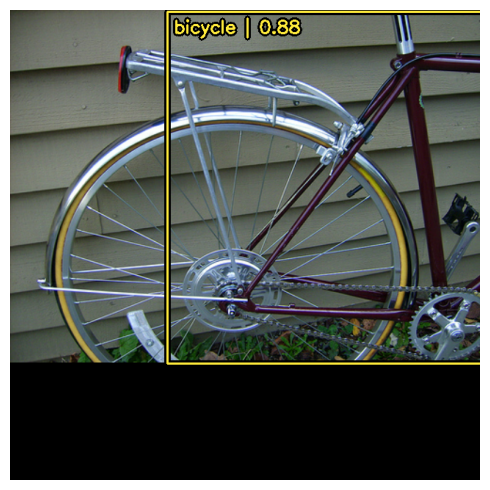


================ RESULTS TABLE ================



,Image,Expected VOC Class (what you chose),Detected Correctly?,Confidence (for expected class),Top detections (label(score)),Missed GT classes (approx)
0,VOC2012_sample_1,person,Yes,0.98,"person(0.98), person(0.94), person(0.94), pers...",chair
1,VOC2012_sample_2,dog,Yes,0.99,"dog(0.99), dog(0.98)",-
2,VOC2012_sample_3,cat,Yes,0.96,cat(0.96),-
3,VOC2012_sample_4,car,No,-,"person(0.92), person(0.89), bus(0.60)",car
4,VOC2012_sample_5,bicycle,Yes,0.88,bicycle(0.88),-


In [1]:
!pip -q install -U "tensorflow>=2.16" "keras>=3.0.0" "keras-cv>=0.9.0" tensorflow-datasets pandas matplotlib

import numpy as np
import pandas as pd
import tensorflow as tf
import tensorflow_datasets as tfds
import keras
import keras_cv
import matplotlib.pyplot as plt
from keras_cv import visualization

print("tf:", tf.__version__)
print("keras:", keras.__version__)
print("keras_cv:", keras_cv.__version__)

# -----------------------------
# 0) Pascal VOC classes
# -----------------------------
voc_classes = [
    "aeroplane","bicycle","bird","boat","bottle","bus","car","cat","chair","cow",
    "diningtable","dog","horse","motorbike","person","pottedplant","sheep","sofa","train","tvmonitor"
]
class_mapping = {i: name for i, name in enumerate(voc_classes)}

def tfds_label_to_name(lbl):
    lbl_int = int(lbl)
    return class_mapping.get(lbl_int, None)

# -----------------------------
# 1) Load Pascal VOC 2012 (TFDS)
# -----------------------------
ds = tfds.load("voc/2012", split="train", shuffle_files=False)

# Choose 5 VOC classes (different classes)
TARGET_CLASSES = ["person", "dog", "cat", "car", "bicycle"]

# Pick the N-th match for each class (CHANGE these to get different images)
PICK_INDEX = {
    "person": 8,
    "dog": 12,
    "cat": 15,
    "car": 10,
    "bicycle": 7,
}

picked = {}
seen_count = {t: 0 for t in TARGET_CLASSES}

print("\nSearching for different images in VOC2012...")
print("TARGET_CLASSES:", TARGET_CLASSES)
print("PICK_INDEX:", PICK_INDEX)

for ex in tfds.as_numpy(ds):
    img = ex["image"]  # uint8 HxWx3
    gt_labels = ex["objects"]["label"]
    gt_names = [tfds_label_to_name(l) for l in gt_labels]
    gt_names = [n for n in gt_names if n is not None]
    gt_set = set(gt_names)

    for t in TARGET_CLASSES:
        if t in picked:
            continue
        if t in gt_set:
            seen_count[t] += 1
            if seen_count[t] == PICK_INDEX[t]:
                picked[t] = {"image": img, "gt_names": gt_names}
                print(f"✅ Picked '{t}' at match #{seen_count[t]} | GT in image: {sorted(gt_set)}")

    if len(picked) == len(TARGET_CLASSES):
        break

if len(picked) < len(TARGET_CLASSES):
    missing = [t for t in TARGET_CLASSES if t not in picked]
    raise RuntimeError(
        f"Could not find images for: {missing}. "
        f"Try smaller PICK_INDEX values (current seen counts: {seen_count})."
    )

samples = [(t, picked[t]["image"], picked[t]["gt_names"]) for t in TARGET_CLASSES]

# -----------------------------
# 2) REQUIRED resizing layer
# -----------------------------
inference_resizing = keras_cv.layers.Resizing(
    640, 640, pad_to_aspect_ratio=True, bounding_box_format="xywh"
)

# -----------------------------
# 3) YOLOv8 PascalVOC preset + decoder (prevents box explosion)
# -----------------------------
prediction_decoder = keras_cv.layers.NonMaxSuppression(
    bounding_box_format="xywh",
    from_logits=False,          # IMPORTANT
    iou_threshold=0.5,
    confidence_threshold=0.5,
)

model = keras_cv.models.YOLOV8Detector.from_preset(
    "yolo_v8_m_pascalvoc",
    bounding_box_format="xywh",
    prediction_decoder=prediction_decoder,
)

# -----------------------------
# 4) Inference + visualization + results table
# -----------------------------
def preds_to_label_scores(preds):
    conf = preds["confidence"][0]
    cls = preds["classes"][0]
    valid = conf > 0
    out = []
    for c, s in zip(cls[valid], conf[valid]):
        c = int(c)
        if c in class_mapping:
            out.append((class_mapping[c], float(s)))
    out.sort(key=lambda x: x[1], reverse=True)
    return out

rows = []

for idx, (target, img, gt_names) in enumerate(samples, start=1):
    img_batch = inference_resizing([img])  # (1, 640, 640, 3)

    preds = model.predict(img_batch, verbose=0)

    print(f"\n=== Image {idx}/5 | Target class: {target} | GT objects: {sorted(set(gt_names))} ===")
    visualization.plot_bounding_box_gallery(
        img_batch,
        value_range=(0, 255),
        rows=1,
        cols=1,
        y_pred=preds,
        scale=5,
        font_scale=0.8,
        bounding_box_format="xywh",
        class_mapping=class_mapping,
        show=True,
    )
    plt.show()

    dets = preds_to_label_scores(preds)
    detected_labels = [lab for lab, _ in dets]

    correct_detected = "Yes" if target in detected_labels else "No"
    target_conf = next((sc for lab, sc in dets if lab == target), None)

    top5 = dets[:5]
    top_text = ", ".join([f"{lab}({sc:.2f})" for lab, sc in top5]) if top5 else "(no detections)"

    missed = sorted(set(gt_names) - set(detected_labels))
    missed_text = ", ".join(missed) if missed else "-"

    rows.append([
        f"VOC2012_sample_{idx}",
        target,
        correct_detected,
        (f"{target_conf:.2f}" if target_conf is not None else "-"),
        top_text,
        missed_text
    ])

df = pd.DataFrame(
    rows,
    columns=[
        "Image",
        "Expected VOC Class (what you chose)",
        "Detected Correctly?",
        "Confidence (for expected class)",
        "Top detections (label(score))",
        "Missed GT classes (approx)"
    ]
)

print("\n================ RESULTS TABLE ================\n")
df